# [Super AI Engineer Season 6] Hackathon Week 6
## 5 Domains Hackathon: Thai Math VQA Challenge

**Super AI Engineer Season 6 - Level 2 Hackathon**  
- Dataset: Thai Math VQA Challenge
- Notebook: Original Qwen2.5-VL self-consistency pipeline
- จัดทำโดย: 600425-วิศิษฐ์

---
### Notebook Outline
1. Setup & Configuration  
2. Data Loading & EDA  
3. Answer Normalization & Local Metric  
4. Model Loading  
5. Prompt Engineering & Self-Consistency  
6. Quick Validation  
7. Full Test Set Inference  
8. Build Submission File  
9. Low-Confidence Analysis

# 1. Setup & Configuration
### 1.1 Prepare the runtime before loading the model

Set the Kaggle paths, GPU-related options, and model settings before starting the VLM workflow.

In [1]:
# ติดตั้ง dependency ที่จำเป็น
!pip -q install -U transformers accelerate qwen-vl-utils sentencepiece bitsandbytes kagglehub 2>/dev/null

import os
import re
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ─── PATH CONFIG ────────────────────────────────────────────────────────────
DATASET_SLUG   = 'super-ai-engineer-ss-6-individual-test-thai-math-vqa-challen'
KAGGLE_MODE    = Path('/kaggle/input').exists()
WORK_DIR       = Path('/kaggle/working') if KAGGLE_MODE else Path('Level 2/Hackathon 9_5 Domains Hackathon/Math VQA Challenge')
WORK_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR_CANDIDATES = [
    Path('/kaggle/input/competitions') / DATASET_SLUG,
    Path('/kaggle/input') / DATASET_SLUG,
    Path(f'Level 2/Hackathon 9_5 Domains Hackathon/Math VQA Challenge') / DATASET_SLUG,
    Path(DATASET_SLUG),
    Path('.'),
]

def find_dataset_dir(candidates):
    for candidate in candidates:
        if (candidate / 'train.csv').exists() and (candidate / 'test.csv').exists():
            return candidate
    raise FileNotFoundError(f'Cannot find dataset from: {candidates}')

DATA_DIR = find_dataset_dir(DATA_DIR_CANDIDATES)

# ─── INFERENCE CONFIG ────────────────────────────────────────────────────────
# Model options (เลือก 1):
#   'Qwen/Qwen2.5-VL-7B-Instruct'   → ดีที่สุดสำหรับ math VQA บน GPU
#   'Qwen/Qwen2-VL-7B-Instruct'     → รุ่นเก่ากว่า แต่ยังดี
#   'Qwen/Qwen2.5-VL-3B-Instruct'   → เบากว่า ถ้า 7B OOM
MODEL_ID             = os.environ.get('VLM_MODEL_ID', 'Qwen/Qwen2.5-VL-7B-Instruct')
MODEL_DIR            = os.environ.get('VLM_MODEL_DIR', '').strip()  # override ถ้ามี local weights
USE_4BIT             = os.environ.get('USE_4BIT', '1') == '1'      # 4-bit quantization
MAX_NEW_TOKENS       = 512     # CoT ต้องการมากขึ้น
SELF_CONSISTENCY_N   = 3       # จำนวน sampling passes (3=เร็ว, 5=แม่นขึ้น)
SELF_CONSISTENCY_TEMP= 0.7     # temperature สำหรับ sampling
SCORE_THRESHOLD      = 0.0     # เลือกเฉพาะ answer ที่ normalize ไม่ว่าง

PREDICTION_CACHE_PATH = WORK_DIR / 'math_vqa_v2_predictions.csv'
SUBMISSION_PATH       = WORK_DIR / 'submission_v2.csv'

print(f'KAGGLE_MODE  : {KAGGLE_MODE}')
print(f'DATA_DIR     : {DATA_DIR.resolve()}')
print(f'WORK_DIR     : {WORK_DIR.resolve()}')
print(f'MODEL_ID     : {MODEL_ID}')
print(f'USE_4BIT     : {USE_4BIT}')
print(f'SC_N         : {SELF_CONSISTENCY_N}')

KAGGLE_MODE  : True
DATA_DIR     : /kaggle/input/competitions/super-ai-engineer-ss-6-individual-test-thai-math-vqa-challen
WORK_DIR     : /kaggle/working
MODEL_ID     : Qwen/Qwen2.5-VL-7B-Instruct
USE_4BIT     : True
SC_N         : 3


# 2. Data Loading & EDA
### 2.1 Load tables and resolve images

Read the train and test metadata, connect each row to its image file, and inspect the answer distribution.

In [2]:
train          = pd.read_csv(DATA_DIR / 'train.csv',          dtype={'id': str})
test           = pd.read_csv(DATA_DIR / 'test.csv',           dtype={'id': str})
sample_sub     = pd.read_csv(DATA_DIR / 'sample_submission.csv', dtype={'id': str})
sample_sub['answer'] = sample_sub['answer'].astype(str)

def resolve_image_path(image_path, data_dir=DATA_DIR):
    raw  = str(image_path)
    name = Path(raw).name
    for candidate in [
        data_dir / raw,
        data_dir / name,
        data_dir / 'images' / name,
        data_dir / 'images' / 'images' / name,
    ]:
        if candidate.exists():
            return candidate
    hits = list(data_dir.rglob(name))
    return hits[0] if hits else None

train['resolved_image_path'] = train['image_path'].map(resolve_image_path)
test['resolved_image_path']  = test['image_path'].map(resolve_image_path)

print(f'Train: {len(train)} rows | Missing images: {train["resolved_image_path"].isna().sum()}')
print(f'Test : {len(test)} rows  | Missing images: {test["resolved_image_path"].isna().sum()}')
print(f'Sample sub: {len(sample_sub)} rows')
print(f'IDs match: {set(sample_sub["id"]) == set(test["id"])}')
display(train.head(5))

Train: 280 rows | Missing images: 0
Test : 420 rows  | Missing images: 0
Sample sub: 420 rows
IDs match: True


,id,image_path,answer,resolved_image_path
0,0,images/0.jpg,20 ตารางเซนติเมตร,/kaggle/input/competitions/super-ai-engineer-s...
1,102,images/102.jpg,76,/kaggle/input/competitions/super-ai-engineer-s...
2,104,images/104.jpg,45,/kaggle/input/competitions/super-ai-engineer-s...
3,105,images/105.jpg,192,/kaggle/input/competitions/super-ai-engineer-s...
4,106,images/106.jpg,2,/kaggle/input/competitions/super-ai-engineer-s...


=== Answer Types in Train ===
Total rows         : 280
Unique answers     : 198
Has LaTeX          : 28
Has Thai digits    : 0
Has <n/a>          : 2
Has Thai text      : 79

Top 20 answers:
answer
1               13
2               12
3               11
4               10
5                9
8                5
36               4
6                3
14               3
45               3
17               3
80 องศา          3
192              2
76               2
9                2
200              2
15 หน่วย         2
12               2
18               2
6 ตารางหน่วย     2


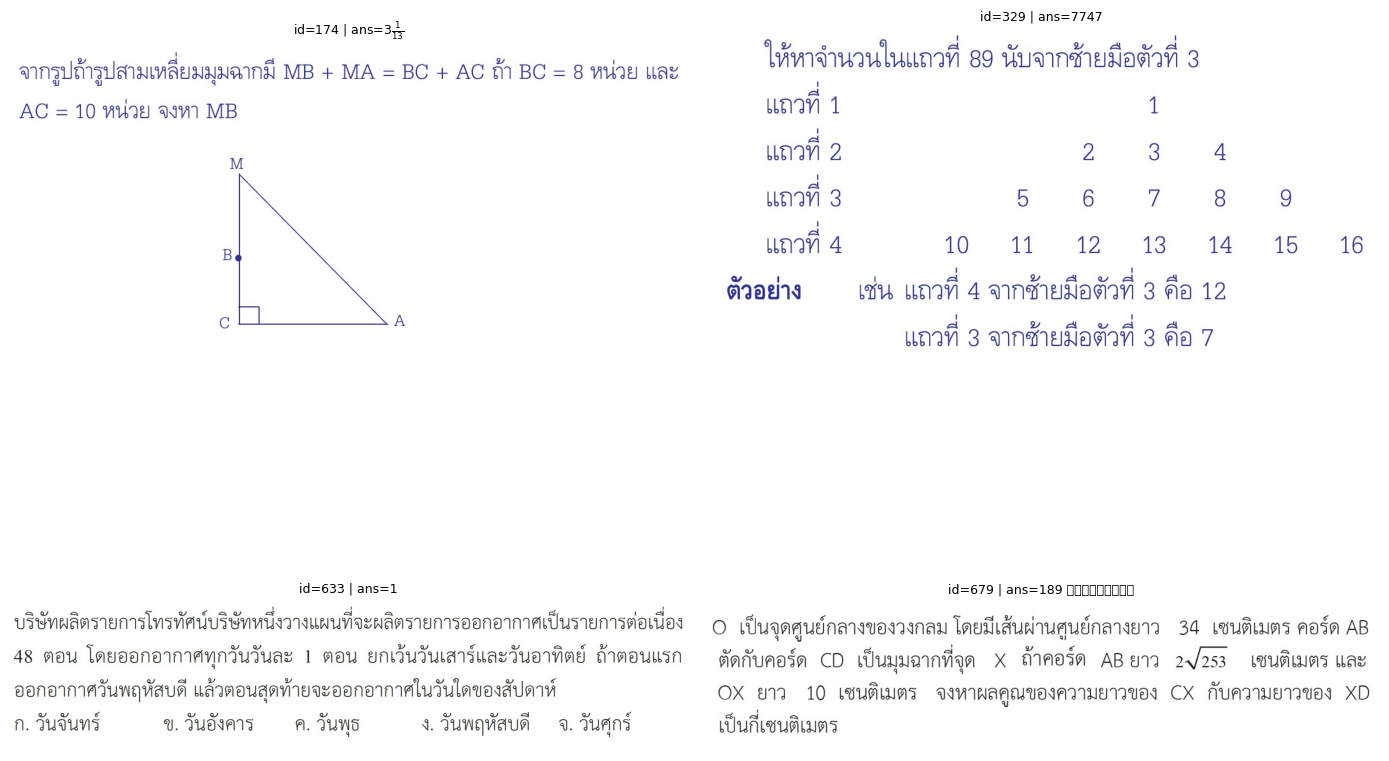

In [3]:
# วิเคราะห์รูปแบบคำตอบ
print('=== Answer Types in Train ===')
print(f'Total rows         : {len(train)}')
print(f'Unique answers     : {train["answer"].nunique()}')
print(f'Has LaTeX          : {train["answer"].astype(str).str.contains(r"\\\\|\$", regex=True).sum()}')
print(f'Has Thai digits    : {train["answer"].astype(str).str.contains("[๐-๙]", regex=True).sum()}')
print(f'Has <n/a>          : {(train["answer"].astype(str) == "<n/a>").sum()}')
print(f'Has Thai text      : {train["answer"].astype(str).str.contains("[ก-ฮ]", regex=True).sum()}')
print()
print('Top 20 answers:')
print(train['answer'].value_counts().head(20).to_string())

# Preview ตัวอย่างโจทย์
preview_rows = train.dropna(subset=['resolved_image_path']).sample(min(4, len(train)), random_state=SEED)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (_, row) in zip(axes.flatten(), preview_rows.iterrows()):
    img = Image.open(row['resolved_image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f"id={row['id']} | ans={row['answer'][:40]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 3. Answer Normalization & Local Metric
### 3.1 Normalize answers consistently

Use the same answer cleanup logic for validation, voting, and submission so exact-match scoring is as fair as possible.

In [4]:
THAI_DIGIT_TABLE = str.maketrans('๐๑๒๓๔๕๖๗๘๙', '0123456789')

UNIT_WORDS = sorted(set([
    'ตารางเซนติเมตร','ลูกบาศก์เซนติเมตร','ลูกบาศก์หน่วย','เซนติเมตร','มิลลิเมตร','เมตร',
    'กิโลเมตร','องศา','หน่วย','จำนวน','วิธี','แบบ','ค่า','ร้อยละ','เปอร์เซ็นต์',
    'บาท','ดอลลาร์','ปี','เดือน','วัน','ชั่วโมง','นาที','วินาที',
    'square centimeters','square centimetre','cubic centimeters','cubic centimetre',
    'centimeters','centimetre','centimeter','degrees','degree','years old','baht','dollars',
]), key=len, reverse=True)

def expand_latex(text):
    s = text
    s = re.sub(r'\\sqrt\s*\{([^{}]+)\}', r'sqrt(\1)', s)
    s = re.sub(r'\\sqrt\s*([0-9a-zA-Z]+)', r'sqrt(\1)', s)
    for _ in range(5):
        ns = re.sub(r'\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}', r'\1/\2', s)
        if ns == s: break
        s = ns
    for old, new in [(r'\pi','pi'),(r'\times','*'),(r'\cdot','*'),(r'\div','/')]:
        s = s.replace(old, new)
    s = re.sub(r'\\(?:left|right|,|;|:|!|overline|vec)', '', s)
    return s

def normalize_answer(value):
    if pd.isna(value): return ''
    s = str(value).strip().lower()
    if s in {'', 'nan', 'none', '<n/a>'}: return ''
    s = s.translate(THAI_DIGIT_TABLE)
    s = s.replace('$', '')
    s = expand_latex(s)
    for unit in UNIT_WORDS:
        s = s.replace(unit.lower(), '')
    s = re.sub(r'[\s{}\\,]', '', s)
    s = re.sub(r'^\((-?\d+)\)$', r'\1', s)
    if re.fullmatch(r'[+-]?\d+(?:\.0+)?', s):
        try: return str(int(float(s)))
        except: return s
    return s

def normalized_accuracy(y_true, y_pred):
    t = [normalize_answer(x) for x in y_true]
    p = [normalize_answer(x) for x in y_pred]
    return float(np.mean([a == b for a, b in zip(t, p)]))

# ตรวจ normalizer
examples = [
    '20 ตารางเซนติเมตร', '30 องศา', '$6\\sqrt{3}$', '$\\frac{17}{10}$',
    '๒๕', '2.0', '$\\frac{3\\sqrt{3}}{2}$', '$48\\pi$ ตารางหน่วย', 'x=70,y=24',
]
for ex in examples:
    print(f'{ex:40s}  →  {normalize_answer(ex)}')

20 ตารางเซนติเมตร                         →  20
30 องศา                                   →  30
$6\sqrt{3}$                               →  6sqrt(3)
$\frac{17}{10}$                           →  17/10
๒๕                                        →  25
2.0                                       →  2
$\frac{3\sqrt{3}}{2}$                     →  3sqrt(3)/2
$48\pi$ ตารางหน่วย                        →  48piตาราง
x=70,y=24                                 →  x=70y=24


# 4. Model Loading
### 4.1 Load Qwen2.5-VL for image reasoning

Load the vision-language model and processor with memory-aware settings for Kaggle GPU inference.

In [7]:
import torch
from transformers import AutoProcessor

try:
    from transformers import Qwen2_5_VLForConditionalGeneration as VLMClass
    print('Using Qwen2.5-VL')
except ImportError:
    try:
        from transformers import Qwen2VLForConditionalGeneration as VLMClass
        print('Using Qwen2-VL')
    except ImportError:
        from transformers import AutoModelForVision2Seq as VLMClass
        print('Using AutoModelForVision2Seq')

try:
    from transformers import BitsAndBytesConfig
    HAS_BNB = True
except ImportError:
    HAS_BNB = False

# โหลด model source
if MODEL_DIR and Path(MODEL_DIR).exists():
    model_source = MODEL_DIR
    print(f'Using local model: {model_source}')
else:
    # ลองใช้ kagglehub ก่อน
    try:
        import kagglehub
        print('Downloading model via kagglehub...')
        model_source = kagglehub.model_download('qwen-lm/qwen2.5-vl/transformers/7b-instruct')
        print(f'Downloaded to: {model_source}')
    except Exception as e:
        print(f'kagglehub failed: {e}')
        # Fallback: โหลด 3B ถ้า 7B ไม่ได้
        model_source = MODEL_ID
        print(f'Falling back to HF Hub: {model_source}')

# Quantization config
quant_config = None
if USE_4BIT and torch.cuda.is_available() and HAS_BNB:
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    print('Using 4-bit quantization')

# โหลด processor
processor = AutoProcessor.from_pretrained(model_source, trust_remote_code=True)

# โหลด model
model = VLMClass.from_pretrained(
    model_source,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map='auto' if torch.cuda.is_available() else None,
    quantization_config=quant_config,
    trust_remote_code=True,
    attn_implementation='flash_attention_2' if torch.cuda.is_available() else 'eager',
)
model.eval()

print(f'\n✅ Model loaded!')
print(f'   Device: {next(model.parameters()).device}')
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    print(f'   GPU Memory: {allocated:.2f} GB')

Using Qwen2.5-VL
Downloaded to: /kaggle/input/models/qwen-lm/qwen2.5-vl/transformers/7b-instruct/2


ValueError: Unrecognized image processor in /kaggle/input/models/qwen-lm/qwen2.5-vl/transformers/7b-instruct/2. Should have a `image_processor_type` key in its preprocessor_config.json of config.json, or one of the following `model_type` keys in its config.json: aimv2, aimv2_vision_model, align, altclip, aria, aya_vision, beit, bit, blip, blip-2, bridgetower, chameleon, chinese_clip, clip, clipseg, cohere2_vision, colpali, colqwen2, conditional_detr, convnext, convnextv2, cvt, data2vec-vision, deepseek_vl, deepseek_vl_hybrid, deformable_detr, deit, depth_anything, depth_pro, detr, dinat, dinov2, dinov3_vit, donut-swin, dpt, edgetam, efficientloftr, efficientnet, emu3, eomt, ernie4_5_vl_moe, flava, florence2, focalnet, fuyu, gemma3, gemma3n, git, glm46v, glm4v, glm_image, glpn, got_ocr2, grounding-dino, groupvit, hiera, idefics, idefics2, idefics3, ijepa, imagegpt, instructblip, internvl, janus, kosmos-2, kosmos-2.5, layoutlmv2, layoutlmv3, layoutxlm, levit, lfm2_vl, lightglue, lighton_

# 5. Prompt Engineering & Self-Consistency
### 5.1 Ask for a short final answer

Use a focused prompt and multiple answer attempts when time allows, then choose the most stable normalized answer.

In [ ]:
# ─── Prompt ที่ดีที่สุดสำหรับ Thai Math VQA ────────────────────────────────
MATH_VQA_PROMPT = """You are an expert Thai math tutor. Look at this Thai mathematics problem image carefully.

Instructions:
1. Read ALL text in the image, including Thai text, mathematical symbols, tables, and geometric figures.
2. Solve the problem step by step (show your reasoning).
3. Write your FINAL ANSWER in the tag <answer>...</answer>.

Answer format rules:
- Use Arabic digits (0-9), not Thai digits
- Fractions: write as 17/10 or 3/4
- Square roots: write as 6sqrt3 or sqrt(10)
- Pi: write as pi (e.g., 48pi)
- Degrees: just write the number (e.g., 45)
- If multiple-choice: write only the answer value, not the option letter
- Keep the answer concise (no units, no explanation inside <answer> tag)

Now solve the problem:""".strip()


# ─── Answer extractor ───────────────────────────────────────────────────────
ANSWER_PATTERNS = [
    r'<answer>\s*(.*?)\s*</answer>',
    r'\\boxed\{([^{}]+)\}',
    r'(?:final\s+answer|the\s+answer)\s*(?:is|=|:)\s*["\']?([^\n"\'\.]+)',
    r'(?:answer|คำตอบ)\s*(?:คือ|is|=|:)?\s*["\']?([^\n"\'\.]{1,40})',
    r'=\s*([+-]?[\d./]+(?:sqrt[\w()]+)?(?:pi)?(?:/[\d.]+)?)',
]

def extract_answer(text: str) -> str:
    if not text: return ''
    s = str(text).strip()
    for pattern in ANSWER_PATTERNS:
        m = re.search(pattern, s, re.IGNORECASE | re.DOTALL)
        if m:
            candidate = m.group(1).strip()
            candidate = re.sub(r'</?answer>', '', candidate, flags=re.IGNORECASE).strip()
            candidate = candidate.split('\n')[0].strip().strip('`*"\'.')
            if len(candidate) <= 100 and candidate:
                return candidate
    # fallback: บรรทัดสุดท้ายที่ไม่ว่าง
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    return lines[-1][:80] if lines else ''


print('Prompt length:', len(MATH_VQA_PROMPT))
print('\nPrompt preview:')
print(MATH_VQA_PROMPT[:300] + '...')

In [ ]:
def run_single_inference(image_path: Path, prompt_text: str, temperature: float = 0.0) -> str:
    """
    รัน VLM inference ครั้งเดียว
    temperature=0 → greedy (deterministic)
    temperature>0 → sampling (สำหรับ self-consistency)
    """
    messages = [{
        'role': 'user',
        'content': [
            {'type': 'image', 'image': str(image_path)},
            {'type': 'text',  'text': prompt_text},
        ],
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    try:
        from qwen_vl_utils import process_vision_info
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, videos=video_inputs,
            padding=True, return_tensors='pt',
        )
    except Exception:
        img = Image.open(image_path).convert('RGB')
        inputs = processor(text=[text], images=[img], padding=True, return_tensors='pt')

    device = next(model.parameters()).device
    inputs = inputs.to(device)

    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=(temperature > 0),
    )
    if temperature > 0:
        gen_kwargs.update(temperature=temperature, top_p=0.9)

    with torch.no_grad():
        generated_ids = model.generate(**inputs, **gen_kwargs)

    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated_ids)]
    return processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]


def run_self_consistency(image_path: Path, n: int = SELF_CONSISTENCY_N) -> dict:
    """
    Self-Consistency: รัน N ครั้ง แล้ว majority vote บน normalized answer
    """
    outputs = []
    answers_raw  = []
    answers_norm = []

    for i in range(n):
        temperature = 0.0 if i == 0 else SELF_CONSISTENCY_TEMP
        try:
            raw_output = run_single_inference(image_path, MATH_VQA_PROMPT, temperature)
            ans_raw    = extract_answer(raw_output)
            ans_norm   = normalize_answer(ans_raw)
        except Exception as e:
            raw_output = f'ERROR:{e}'
            ans_raw    = ''
            ans_norm   = ''

        outputs.append(raw_output)
        answers_raw.append(ans_raw)
        answers_norm.append(ans_norm)

    # Majority vote (ไม่นับ empty answers)
    valid_norms = [a for a in answers_norm if a]
    if valid_norms:
        vote_counter = Counter(valid_norms)
        best_norm    = vote_counter.most_common(1)[0][0]
        # ดึง raw answer ที่ตรงกับ best_norm
        best_raw     = next(
            (answers_raw[i] for i, n in enumerate(answers_norm) if n == best_norm),
            answers_raw[0]
        )
        confidence   = vote_counter.most_common(1)[0][1] / n
    else:
        best_norm    = ''
        best_raw     = ''
        confidence   = 0.0

    return {
        'outputs'        : outputs,
        'answers_raw'    : answers_raw,
        'answers_norm'   : answers_norm,
        'best_answer_raw': best_raw,
        'best_answer_norm': best_norm,
        'confidence'     : confidence,
    }


print('Inference functions ready!')

# 6. Quick Validation
### 6.1 Test the pipeline on a small sample

Run a small validation pass to check image loading, prompting, answer extraction, and local accuracy before full inference.

In [ ]:
from sklearn.model_selection import train_test_split

train_meta, valid_meta = train_test_split(train, test_size=0.2, random_state=SEED)

# Most-common baseline score
most_common_answer = train_meta['answer'].mode().iloc[0]
baseline_score = normalized_accuracy(valid_meta['answer'], [most_common_answer] * len(valid_meta))
print(f'Most common answer: "{most_common_answer}"')
print(f'Baseline (most common) accuracy: {baseline_score:.4f}')
print()

# Quick validation (10 samples)
VAL_N = 10  # เพิ่มเป็น 20-30 ถ้ามีเวลา
val_sample = valid_meta.dropna(subset=['resolved_image_path']).sample(VAL_N, random_state=SEED)

val_results = []
for _, row in tqdm(val_sample.iterrows(), total=VAL_N, desc='Validating'):
    try:
        result = run_self_consistency(row['resolved_image_path'], n=SELF_CONSISTENCY_N)
        pred   = result['best_answer_norm']
    except Exception as e:
        print(f'ERROR on {row["id"]}: {e}')
        pred   = normalize_answer(most_common_answer)
        result = {'best_answer_norm': pred, 'confidence': 0.0}

    val_results.append({
        'id'         : row['id'],
        'true_answer': row['answer'],
        'true_norm'  : normalize_answer(row['answer']),
        'pred_norm'  : pred,
        'confidence' : result.get('confidence', 0),
        'correct'    : normalize_answer(row['answer']) == pred,
    })

val_df = pd.DataFrame(val_results)
val_acc = val_df['correct'].mean()
print(f'\n✅ Validation Accuracy ({VAL_N} samples): {val_acc:.4f}')
print(f'   Baseline: {baseline_score:.4f}  |  Improvement: {val_acc - baseline_score:+.4f}')
display(val_df[['id', 'true_norm', 'pred_norm', 'confidence', 'correct']])

# 7. Full Test Set Inference
### 7.1 Predict every test image

Run the VLM on the test set, cache intermediate results, and keep the output recoverable if the session stops early.

In [ ]:
# โหลด cache ถ้ามี
if PREDICTION_CACHE_PATH.exists():
    pred_df = pd.read_csv(PREDICTION_CACHE_PATH, dtype={'id': str})
    done_ids = set(pred_df['id'].astype(str))
    print(f'Loaded cache: {len(pred_df)} rows already done')
else:
    pred_df  = pd.DataFrame()
    done_ids = set()

fallback_norm = normalize_answer(most_common_answer)
new_rows = []

for idx, row in tqdm(test.iterrows(), total=len(test), desc='Test inference'):
    row_id = str(row['id'])
    if row_id in done_ids:
        continue

    img_path = row['resolved_image_path']
    if img_path is None or not Path(img_path).exists():
        new_rows.append({
            'id': row_id, 'image_path': row['image_path'],
            'best_answer_raw': fallback_norm,
            'best_answer_norm': fallback_norm,
            'confidence': 0.0,
            'all_answers': str([fallback_norm] * SELF_CONSISTENCY_N),
        })
        continue

    try:
        result = run_self_consistency(img_path, n=SELF_CONSISTENCY_N)
        ans    = result['best_answer_norm'] if result['best_answer_norm'] else fallback_norm
        new_rows.append({
            'id'              : row_id,
            'image_path'      : row['image_path'],
            'best_answer_raw' : result['best_answer_raw'],
            'best_answer_norm': ans,
            'confidence'      : result['confidence'],
            'all_answers'     : str(result['answers_norm']),
        })
    except Exception as e:
        print(f'ERROR on {row_id}: {e}')
        new_rows.append({
            'id': row_id, 'image_path': row['image_path'],
            'best_answer_raw': fallback_norm,
            'best_answer_norm': fallback_norm,
            'confidence': 0.0,
            'all_answers': f'ERROR:{e}',
        })

    # บันทึก cache ทุก 10 รูป
    if len(new_rows) % 10 == 0 and new_rows:
        batch_df = pd.DataFrame(new_rows)
        pred_df  = pd.concat([pred_df, batch_df], ignore_index=True)
        pred_df  = pred_df.drop_duplicates('id', keep='last')
        pred_df.to_csv(PREDICTION_CACHE_PATH, index=False)
        print(f'Cached {len(pred_df)} rows → {PREDICTION_CACHE_PATH}')
        new_rows = []

# บันทึกที่เหลือ
if new_rows:
    batch_df = pd.DataFrame(new_rows)
    pred_df  = pd.concat([pred_df, batch_df], ignore_index=True)
    pred_df  = pred_df.drop_duplicates('id', keep='last')
    pred_df.to_csv(PREDICTION_CACHE_PATH, index=False)
    print(f'Final cache: {len(pred_df)} rows')

print(f'\n✅ Done! Total predictions: {len(pred_df)}')
print(f'   Avg confidence: {pred_df["confidence"].mean():.3f}')
display(pred_df.head(10))

# 8. Build Submission File
### 8.1 Create the Kaggle-ready file

Merge predictions into the sample submission, fill any missing answer with the fallback value, and save the final CSV.

In [ ]:
# Merge predictions กับ sample submission
sub = sample_sub[['id']].copy()
sub['id'] = sub['id'].astype(str)

pred_merged = pred_df[['id', 'best_answer_norm']].copy()
pred_merged['id'] = pred_merged['id'].astype(str)
pred_merged = pred_merged.drop_duplicates('id', keep='last')

sub = sub.merge(pred_merged, on='id', how='left')
sub['answer'] = sub['best_answer_norm'].fillna(fallback_norm).astype(str)
# แทน empty string ด้วย fallback
sub.loc[sub['answer'] == '', 'answer'] = fallback_norm
sub = sub[['id', 'answer']]

# ─── Sanity Checks ───────────────────────────────────────────────────────────
assert list(sub.columns) == ['id', 'answer'],   'Column mismatch!'
assert len(sub) == len(sample_sub),             f'Row count mismatch: {len(sub)} vs {len(sample_sub)}'
assert set(sub['id']) == set(test['id']),        'ID mismatch!'
assert sub['id'].duplicated().sum() == 0,        'Duplicate IDs!'
assert sub['answer'].isna().sum() == 0,          'Missing answers!'
assert (sub['answer'].astype(str).str.len() > 0).all(), 'Empty answers!'

sub.to_csv(SUBMISSION_PATH, index=False)
print(f'✅ Submission saved: {SUBMISSION_PATH}')
print(f'   Shape: {sub.shape}')
print(f'   Unique answers: {sub["answer"].nunique()}')
print(f'   Answer distribution (top 10):')
print(sub['answer'].value_counts().head(10).to_string())
display(sub.head(20))

# 9. Low-Confidence Analysis
### 9.1 Inspect uncertain outputs

Review low-confidence predictions and repeated fallback answers to decide what should be checked manually or rerun.

In [ ]:
if len(pred_df) > 0:
    low_conf = pred_df[pred_df['confidence'] < 0.5].sort_values('confidence')
    print(f'Low confidence predictions (< 0.5): {len(low_conf)} rows')
    display(low_conf[['id', 'best_answer_norm', 'confidence', 'all_answers']].head(10))

    # Distribution ของ confidence
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    pred_df['confidence'].hist(bins=20, edgecolor='black')
    plt.title('Confidence Distribution')
    plt.xlabel('Confidence')
    plt.subplot(1, 2, 2)
    sub['answer'].value_counts().head(15).plot(kind='bar')
    plt.title('Top Predicted Answers')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print('\n=== FINAL SUMMARY ===')
print(f'Total test predictions  : {len(pred_df)}')
print(f'Submission rows         : {len(sub)}')
print(f'Avg confidence          : {pred_df["confidence"].mean():.3f}')
print(f'High confidence (>0.6)  : {(pred_df["confidence"] > 0.6).sum()}')
print(f'Submission path         : {SUBMISSION_PATH}')
print()
print('Next experiments if time permits:')
print('  1. เพิ่ม SELF_CONSISTENCY_N = 5 (ช้าลง 2x แต่แม่นขึ้น)')
print('  2. ลอง Qwen2.5-VL-72B ถ้า runtime ยาวขึ้น')
print('  3. fine-tune model บน train 280 รูป (few-shot LoRA)')